# Import PyTorch

In [1]:
import torch 
import torch.nn as nn
import torch.nn.functional as F

# Load Img dataset
We'll use CIFAR10 because it is tiny.

In [2]:
from torchvision import datasets
from torchvision import transforms

# Define Transform

Images must become tensors.

In [3]:
transform = transforms.ToTensor()

# Dataset

In [4]:
dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=transform
)

c:\Users\dhana\miniconda3\envs\DL_Torch\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


# Inspect Data

In [5]:
print(len(dataset))

50000


# Get One Image

In [6]:
image, label = dataset[0]

In [7]:
label

6

In [8]:
image.shape

torch.Size([3, 32, 32])

3 -> channel

32 -> height

32 -> width

# Visualize

In [9]:
import matplotlib.pyplot as plt

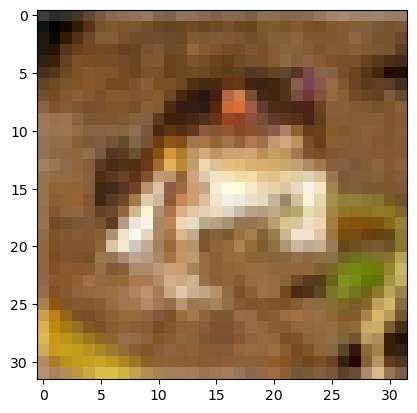

In [10]:
# permute changes the dimenstion
# example 3,32,32 to 32,32,3
# the 1, 2, 0 is the index

plt.imshow(image.permute(1, 2, 0))
plt.show()

# Encoder Part

Image

 ↓

Encoder

 ↓

Representation
______________________

Pixels → Meaningful Features

[3, 32, 32] -> [128] or [256]

# Class For Encoder

In [11]:
class Encoder(nn.Module):
    
    def __init__(self):
        super().__init__()


        self.encoder  = nn.Sequential(

            nn.Conv2d(in_channels = 3, out_channels = 16, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(in_channels = 16, out_channels = 32, kernel_size=3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(in_features = (32 * 8 * 8), out_features = 128)
        )
    
    def forward(self, x):
        return self.encoder(x)

In [12]:
# created model 

# obj encoder for class Encoder()
encoder = Encoder()

In [13]:
image.shape

torch.Size([3, 32, 32])

But PyTorch CNN expects:

(batch, channel, height, width)

so batch is missing

In [14]:
# Add batch Dimension

image_batch = image.unsqueeze(0)
image_batch.shape

torch.Size([1, 3, 32, 32])

batch -> 1
channel -> 3
height -> 32
width -> 32

# Pass the data to encoder

In [15]:
representation = encoder(image_batch)

In [16]:
representation.shape

torch.Size([1, 128])

In [17]:
x = image_batch

for layer in encoder.encoder:
    x = layer(x)
    print(layer.__class__.__name__, x.shape)

Conv2d torch.Size([1, 16, 32, 32])
ReLU torch.Size([1, 16, 32, 32])
MaxPool2d torch.Size([1, 16, 16, 16])
Conv2d torch.Size([1, 32, 16, 16])
ReLU torch.Size([1, 32, 16, 16])
MaxPool2d torch.Size([1, 32, 8, 8])
Flatten torch.Size([1, 2048])
Linear torch.Size([1, 128])


In [18]:
# plt.imshow(representation)
representation.shape

torch.Size([1, 128])

# Testing

In [19]:
image2, _ = dataset[1]

rep1 = encoder(image.unsqueeze(0))
rep2 = encoder(image2.unsqueeze(0))

print(rep1.shape)
print(rep2.shape)

torch.Size([1, 128])
torch.Size([1, 128])


# What JEPA actually learns

lets say we have 2 img
- img A(current frame) and img B(future frame)


    - img A -> Encoder -> ZA
    - img B -> Encoder -> ZB

- but both have same shape after encoding (1, 128)

- So JEPA does'nt predict img B

- it predicts ZB

    - ZA -> predictor -> predicted ZB

- Then compares 
    - predicted ZB vs Actual ZB


# Predictor

In [20]:
class Predictor(nn.Module):

    def __init__(self):
        super().__init__()

        self.predictor = nn.Sequential(
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )

    def forward(self, x):
        return self.predictor(x)

In [21]:
predictor = Predictor()

# To understand

In [22]:
image_1, _ = dataset[0]
image_2, _ = dataset[1]

In [23]:
z1 = encoder(image_1.unsqueeze(0))
z2 = encoder(image_2.unsqueeze(0))

In [24]:
print(z1.shape)
print(z2.shape)

torch.Size([1, 128])
torch.Size([1, 128])


# Now predict the future representation for Z1 to get Z2

In [25]:
pred_z2 = predictor(z1)
pred_z2.shape

torch.Size([1, 128])

image 1 -> encoder -> z1 -> predictor -> pred_z2

image 2 -> encoder -> z2

# Compare Loss (MSE)

In [26]:
loss_fn = nn.MSELoss()

loss = loss_fn(pred_z2, z2)

print(loss)

tensor(0.0152, grad_fn=<MseLossBackward0>)


# Optimizer

In [27]:
optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(predictor.parameters()),
    lr = 0.001
)

In [28]:
optimizer.zero_grad()

z1 = encoder(image_1.unsqueeze(0))
z2 = encoder(image_2.unsqueeze(0))

pred_z2 = predictor(z1)

loss = loss_fn(pred_z2, z2)

loss.backward()

optimizer.step()

print(loss.item())

0.015204313211143017


# You have now performed your first JEPA-style training step.

Image1 → Encoder → Predictor → z2

Image2 → SAME Encoder → z2

This is not JEPA


___________